In [41]:
import numpy as np
import matplotlib.pyplot as plt

In [42]:
# travel scenario
target_distance = 700.0  # km
travel_speed = 110.0  # km/h
min_soc = 20.0
max_soc = 100.0

# consumption parameters
consumption_at_50  = 15.0  # kWh/100km
consumption_at_120 = 17.0  # kWh/100km

# charging parameters
battery_kwh = 80.0
time_20_80 = 20.0   # minutes from 20% to 80%
time_80_100 = 30.0  # minutes from 80% to 100%

In [43]:
def consumption_quadratic(speed_kmh, consumption_at_50, consumption_at_120):
    """Return power consumption in kWh/100km as a quadratic function of speed.

    The model assumes consumption follows a quadratic curve of the form
    c(v) = a*v^2 + c0 and is fitted to the known values at 50 km/h and
    120 km/h.
    """
    a = (consumption_at_120 - consumption_at_50) / (120**2 - 50**2)
    c0 = consumption_at_50 - a * 50**2
    return a * np.array(speed_kmh) ** 2 + c0


def soc_charge_curve(time_min, time_20_80, time_80_100):
    """Return state of charge (%) for a single cubic charging curve.

    The curve is constrained to pass through:
      - 20% at t = 0
      - 80% at t = time_20_80
      - 100% at t = time_20_80 + time_80_100
    and to flatten at 100% with zero slope at the end.
    """
    time_min = np.asarray(time_min, dtype=float)
    t1 = float(time_20_80)
    t2 = float(time_80_100)
    t_end = t1 + t2

    if t_end <= 0:
        return np.full_like(time_min, 20.0)

    # cubic coefficients a*t^3 + b*t^2 + c*t + d
    A = np.array([
        [0.0**3, 0.0**2, 0.0, 1.0],
        [t1**3, t1**2, t1, 1.0],
        [t_end**3, t_end**2, t_end, 1.0],
        [3.0 * t_end**2, 2.0 * t_end, 1.0, 0.0],
    ])
    y = np.array([20.0, 80.0, 100.0, 0.0])
    a, b, c, d = np.linalg.solve(A, y)

    soc = np.polyval([a, b, c, d], time_min)
    return np.clip(soc, 20.0, 100.0)


def travel_distance_over_time(distance_km, speed_kmh, battery_kwh,
                              consumption_at_50, consumption_at_120,
                              time_20_80, time_80_100,
                              min_soc=20.0, max_soc=100.0):
    """Return time, distance and SOC arrays for a trip with charging pauses."""
    if distance_km <= 0 or speed_kmh <= 0 or max_soc <= min_soc:
        return np.array([0.0]), np.array([0.0]), np.array([min_soc])

    consumption = consumption_quadratic(speed_kmh, consumption_at_50, consumption_at_120)
    usable_energy = battery_kwh * (max_soc - min_soc) / 100.0
    range_km = usable_energy / (consumption / 100.0)
    charge_time_h = (time_20_80 + time_80_100) / 60.0
    charge_duration = time_20_80 + time_80_100

    if range_km <= 0:
        return np.array([0.0]), np.array([0.0]), np.array([min_soc])

    times = [0.0]
    distances = [0.0]
    socs = [max_soc]
    remaining = distance_km
    current_time = 0.0
    current_distance = 0.0
    current_soc = max_soc

    while remaining > 1e-3:
        drive_leg = min(remaining, range_km)
        drive_time = drive_leg / speed_kmh
        current_time += drive_time
        current_distance += drive_leg
        current_soc = max_soc - (max_soc - min_soc) * (drive_leg / range_km)
        times.append(current_time)
        distances.append(current_distance)
        socs.append(current_soc)
        remaining -= drive_leg

        if remaining <= 1e-3:
            break

        charge_grid = np.linspace(0.0, charge_duration, 21)
        base_soc = soc_charge_curve(charge_grid, time_20_80, time_80_100)
        scaled_soc = min_soc + (base_soc - 20.0) / 80.0 * (max_soc - min_soc)

        for t_rel, soc in zip(charge_grid[1:], scaled_soc[1:]):
            times.append(current_time + t_rel / 60.0)
            distances.append(current_distance)
            socs.append(soc)

        current_time += charge_time_h
        current_soc = max_soc

    return np.array(times), np.array(distances), np.array(socs)

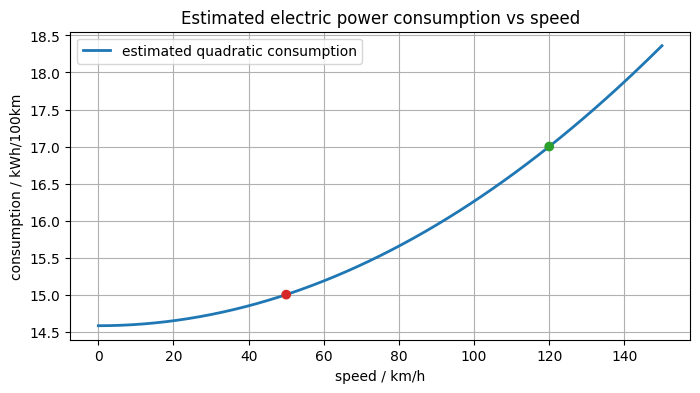

In [44]:
speed_range = np.linspace(0, 150, 151)
consumption_curve = consumption_quadratic(speed_range, consumption_at_50, consumption_at_120)

plt.figure(figsize=(8, 4))
plt.plot(speed_range, consumption_curve, color="tab:blue", linewidth=2, label="estimated quadratic consumption")
plt.scatter([50, 120], [consumption_at_50, consumption_at_120], color=["tab:red", "tab:green"], zorder=5)
plt.xlabel("speed / km/h")
plt.ylabel("consumption / kWh/100km")
plt.title("Estimated electric power consumption vs speed")
plt.grid(True)
plt.legend()
plt.show()

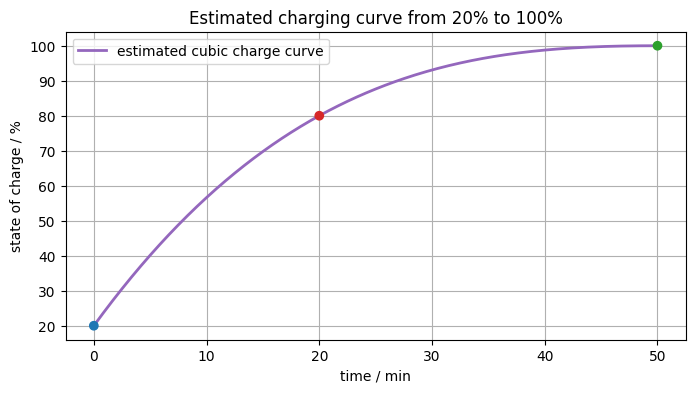

In [45]:
charge_time = np.linspace(0, time_20_80 + time_80_100, 301)
charge_curve = soc_charge_curve(charge_time, time_20_80, time_80_100)

plt.figure(figsize=(8, 4))
plt.plot(charge_time, charge_curve, color="tab:purple", linewidth=2, label="estimated cubic charge curve")
plt.scatter([0, time_20_80, time_20_80 + time_80_100], [20, 80, 100], color=["tab:blue", "tab:red", "tab:green"], zorder=5)
plt.xlabel("time / min")
plt.ylabel("state of charge / %")
plt.title("Estimated charging curve from 20% to 100%")
plt.grid(True)
plt.legend()
plt.show()

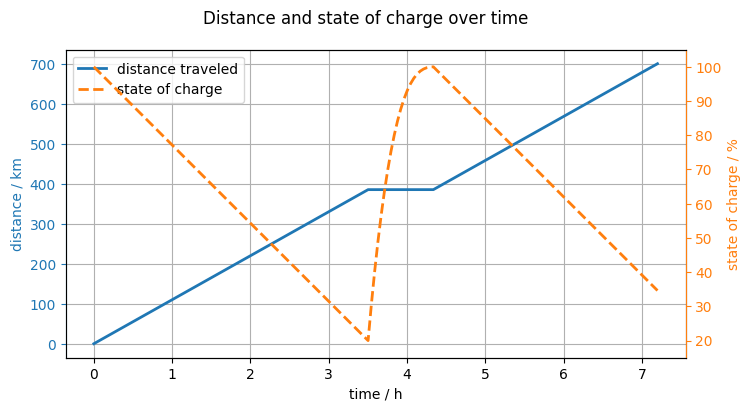

Estimated usable range: 385 km
Total trip time: 7.20 h


In [46]:
trip_time, trip_distance, trip_soc = travel_distance_over_time(
    target_distance,
    travel_speed,
    battery_kwh,
    consumption_at_50,
    consumption_at_120,
    time_20_80,
    time_80_100,
    min_soc=min_soc,
    max_soc=max_soc,
)

fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(trip_time, trip_distance, color='tab:blue', linewidth=2, label='distance traveled')
ax1.set_xlabel('time / h')
ax1.set_ylabel('distance / km', color='tab:blue')
ax1.tick_params(axis='y', colors='tab:blue')
ax1.spines['left'].set_color('tab:blue')
ax1.grid(True)

ax2 = ax1.twinx()
ax2.plot(trip_time, trip_soc, color='tab:orange', linestyle='--', linewidth=2, label='state of charge')
ax2.set_ylabel('state of charge / %', color='tab:orange')
ax2.tick_params(axis='y', colors='tab:orange')
ax2.spines['right'].set_color('tab:orange')
ax2.set_ylim(min_soc - 5, max_soc + 5)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
fig.suptitle('Distance and state of charge over time')
plt.show()

print(f"Estimated usable range: {battery_kwh * (max_soc - min_soc) / 100.0 / (consumption_quadratic(travel_speed, consumption_at_50, consumption_at_120) / 100):.0f} km")
print(f"Total trip time: {trip_time[-1]:.2f} h")
